# A PhotoRing Analysis of Kepler-51
## Contours plot of PR effect

This notebook contains the code for reproducing the figures in the paper:

> S. Numpaque, J.I. Zuluaga, D. Kipping and J.A. Alvarado "Asterodensity profile analysis of the Kepler-51 planetary system:1
a case study on the detection of exoplanetary rings via the PhotoRing effect", in preparation.

For detailed explanations see the GitHub repository: [https://github.com/seap-udea/PRisma](https://github.com/seap-udea/PRisma).

## Preparing environment

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import geotrans as geo

## Define the System

Here we define the planetary `system` explicitly, in this case a Saturn-like planet around a solar-like star. All the definitions are self-explanatory. We use the constants defined in the package `geotrans` provided with this notebook:

In [2]:
system = geo.dict2obj(dict(
    #########################################
    # SYSTEM PRIMARY PARAMETERS
    #########################################
    description="Saturn analogue",
    # //////////////////////////////
    # DETECTOR
    # //////////////////////////////
    Ddet=0.5,       # Aperture, m
    qeff=1.0,       # Quantum efficiency
    # //////////////////////////////
    # STAR
    # //////////////////////////////
    Mstar=1.0*geo.MSUN,
    Rstar=1.0*geo.RSUN,
    Lstar=1.0*geo.LSUN,
    Tstar=1.0*geo.TSUN,
    Dstar=1*geo.KILO*geo.PARSEC,
    c1=0.70,        # Limb Darkening
    c2=-0.24,       # Limb Darkening
    # //////////////////////////////
    # ORBIT
    # //////////////////////////////
    ap=0.1*geo.AU,
    ep=0.0,
    iorb=90.0*geo.DEG,
    wp=0.0*geo.DEG,
    # //////////////////////////////
    # PLANET
    # //////////////////////////////
    Mplanet=1.0*geo.MSAT,
    Rplanet=1.0*geo.RSAT,
    fp=0.0,         # Oblateness
    # //////////////////////////////
    # RINGS
    # //////////////////////////////
    fe=geo.RSAT_ARING/geo.RSAT, # Exterior ring (Rp)
    fi=geo.RSAT_BRING/geo.RSAT, # Interior ring (Rp)
    ir=10.0*geo.DEG,        # Ring inclination
    phir=60.0*geo.DEG,      # Ring roll angle
    tau=1.0,            # Opacity
))

#########################################
# SYSTEM DERIVATIVE PARAMETERS
#########################################
geo.derivedSystemProperties(system)
geo.updatePlanetRings(system)
geo.updatePosition(system, system.tcen)

## Define the Calculation Function

Here we define the `compute_photoring_contour` function, which is responsible for computing the PhotoRing ratio (PR) and the transit depth proxy ($\delta$).

In [3]:
def compute_photoring_contour(
    ringed_system,
    *,
    cieff_min: float = 0.01,
    cieff_max: float = 1.0,
    n_cieff: int = 81,
    teff_min: float = 0.0 * geo.DEG,
    teff_max: float = 90.0 * geo.DEG,
    n_teff: int = 73,
):
    ringed = geo.copyObject(ringed_system)

    # Transit/orbit scalings (same definitions as the original code)
    P = ringed.Porb / geo.HOUR
    rho_true = ringed.Mstar / (4 * np.pi / 3 * ringed.Rstar**3)

    cieffs = np.linspace(cieff_min, cieff_max, n_cieff)
    teffs = np.linspace(teff_min, teff_max, n_teff)

    CI, TH = np.meshgrid(cieffs, teffs)  # TH in radians
    PR = np.zeros_like(CI, dtype=float)
    Delta = np.zeros_like(CI, dtype=float)

    from tqdm.auto import tqdm
    for i_idx, ci in enumerate(tqdm(cieffs, desc="Computing PhotoRing contours", leave=False)):
        ieff = np.arccos(ci)
        ringed.ieff = ieff
        ringed.block = geo.blockFactor(ringed.tau, ieff)

        # Update ring projected semiminor axis for this effective inclination
        ringed.Ringext.b = ringed.Ringext.a * np.cos(ieff)
        ringed.Ringint.b = ringed.Ringint.a * np.cos(ieff)

        for t_idx, teff in enumerate(teffs):
            # Update ring tilt orientation
            ringed.Ringext.cost = np.cos(teff)
            ringed.Ringext.sint = np.sin(teff)
            ringed.Ringint.cost = np.cos(teff)
            ringed.Ringint.sint = np.sin(teff)

            # Numerical contact times
            tcsp = geo.contactTimes(ringed)
            tT = (tcsp[-1] - tcsp[1]) / geo.HOUR
            tF = (tcsp[-2] - tcsp[2]) / geo.HOUR

            # Transit depth proxy p = A_RP / np.pi (same as original)
            p = geo.ringedPlanetArea(ringed) / np.pi
            
            # Transit depth delta: ring contribution only
            # Calculate as total area minus planet area
            rp = ringed.Planet.a
            asp = np.pi * rp**2
            aring = geo.ringedPlanetArea(ringed) - asp
            delta = aring / np.pi
            
            # Edge-on configuration: no projected ring area
            if ci < 1e-10:  # np.cos(ieff) ≈ 0 when ieff ≈ 90°
                delta = 0.0

            # PhotoRing ratio: rho_obs / rho_true
            rho_ratio = geo.rhoObserved_Seager(p, ringed.Rstar, tT, tF, P) / rho_true
            PR[t_idx, i_idx] = 10*np.log10(rho_ratio)
            Delta[t_idx, i_idx] = delta

    return CI, TH, PR, Delta, ringed

## Perform the Main Calculations

We calculate the parameters that will be plotted later. This step might take a little while as it iterates over multiple orientations.

In [4]:
CI, TH, PR, Delta, ringed = compute_photoring_contour(system)

Computing PhotoRing contours:   0%|          | 0/81 [00:00<?, ?it/s]

## Define the Plotting Function

We define the `plot_contour` function to generate contour maps with the configured color palette and styling.

In [5]:
def plot_contour(CI, TH, Z, ringed, *, out_path: str, cbar_label: str, draw_zero: bool = False, fmt="%.2f", highlight_contour: float = None):
    import os
    import matplotlib.patheffects as pe
    # Matplotlib-only styling (bold and white background)
    plt.style.use('default')
    plt.rcParams.update(
        {
            "figure.dpi": 150,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.3,
            "grid.color": "gray",
            "grid.linestyle": "--",
            "axes.labelsize": 16,
            "axes.titlesize": 18,
            "axes.titleweight": "bold",
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
            "font.family": "serif",
        }
    )

    fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)

    vmin, vmax = float(np.nanmin(Z)), float(np.nanmax(Z))
    if vmin < 0.0 < vmax:
        from matplotlib import colors
        norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        from matplotlib.colors import LinearSegmentedColormap

        # 1. Get 256 colors from the original intense RdBu colormap
        original_cmap = plt.colormaps['RdBu']
        cmap_colors = original_cmap(np.linspace(0, 1, 256))

        # 2. Blend it with white (e.g., 50% original color + 50% pure white)
        soften_factor = 0.50 
        white = np.ones_like(cmap_colors)
        soft_colors = cmap_colors * (1 - soften_factor) + white * soften_factor

        # 3. Rebuild the new, muted colormap
        cmap = LinearSegmentedColormap.from_list("soft_RdBu", soft_colors)

    else:
        from matplotlib import colors
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap("Blues")

    # Smooth field rendering (no blocky cells): filled contours with many levels
    filled_levels = np.linspace(vmin, vmax, 256)
    cf = ax.contourf(
        CI,
        TH * geo.RAD,
        Z,
        levels=filled_levels,
        cmap=cmap,
        norm=norm,
        antialiased=True,
    )

    levels = np.linspace(vmin, vmax, 9)
    cs = ax.contour(CI, TH * geo.RAD, Z, levels=levels, colors="black", linewidths=0.8, alpha=0.7)
    labels = ax.clabel(cs, fmt=fmt, fontsize=11, inline=True, inline_spacing=4)
    # Give the labels bold text to make them more legible
    for label in labels:
        label.set_fontweight("bold")
        label.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])
        label.set_zorder(100)
    
    if draw_zero and (vmin < 0.0 < vmax):
        ax.contour(CI, TH * geo.RAD, Z, levels=[0.0], colors="black", linewidths=2.5, linestyles="-")
    
    if highlight_contour is not None:
        ax.contour(CI, TH * geo.RAD, Z, levels=[highlight_contour], colors="red", linewidths=2.5, linestyles="--")

    # Keep the ring/planet glyphs (as in original Figure 3)
    fig.canvas.draw()
    bbox = ax.get_window_extent()
    aspect_ratio = bbox.width / bbox.height
    fh_val = 0.03 / ringed.Rp
    fv_val = fh_val * aspect_ratio

    geo.plotPlanets(
        ax,
        ringed,
        xmin=float(np.nanmin(CI)),
        scalex=float(np.nanmax(CI) - np.nanmin(CI)),
        ymin=float(np.nanmin(TH) * geo.RAD),
        scaley=float((np.nanmax(TH) - np.nanmin(TH)) * geo.RAD),
        fh=fh_val,
        fv=fv_val
    )

    ax.set_xlim(float(np.nanmin(CI)), float(np.nanmax(CI)))
    ax.set_ylim(float(np.nanmin(TH) * geo.RAD), float(np.nanmax(TH) * geo.RAD))
    # Text must match the original Figure 3 exactly
    ax.set_xlabel(r"$\cos\,i_{\rm  R}$")
    ax.set_ylabel(r"$\theta_{\rm R}$")
    title_str = rf"{ringed.description}: $R_p = {ringed.Rplanet / 6371e3:.1f}\,R_\oplus$, $f_i = {ringed.fi:.1f}$, $f_e = {ringed.fe:.1f}$"
    fs = 14
    if highlight_contour is not None:
        title_str += f" (Highlighted PR = {highlight_contour})"
        fs = 12
    ax.set_title(title_str, fontsize=fs, pad=20)
    ax.tick_params(direction="out", length=4, width=1)

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = fig.colorbar(cf, cax=cax, format=fmt)
    cbar.set_label(cbar_label)
    cbar.ax.tick_params(direction="out", length=3, width=1)

    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        fig.savefig(out_path, bbox_inches="tight")

    plt.show()

## Plot the PhotoRing Ratio

Here we generate the first contour plot for $PR \equiv \log_{10}(\rho_{\star,\rm obs}/\rho_{\star,\rm true})$.

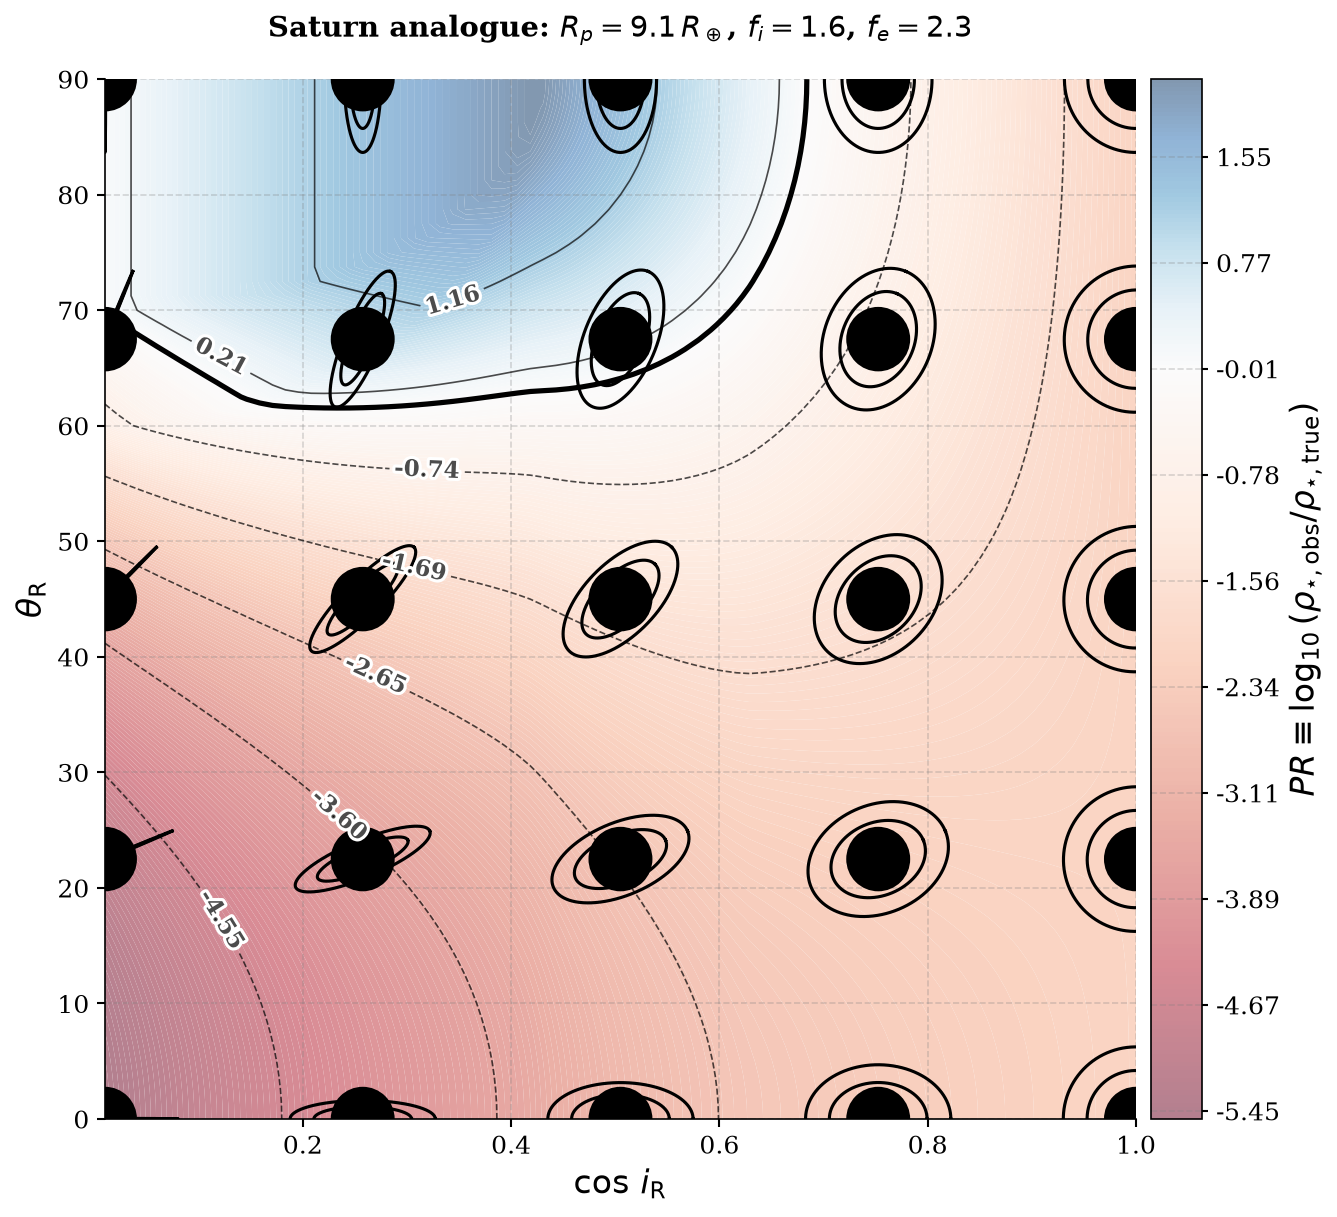

In [6]:
plot_contour(
    CI, TH, PR, ringed, 
    out_path="figures/PRContour-Saturn.png",
    cbar_label=r"$PR\equiv\log_{10}(\rho_{\star,\rm obs}/\rho_{\star,\rm true})$", 
    draw_zero=True
)


We can test with another system, for instance one similar to Kepler-51b:

Computing PhotoRing contours:   0%|          | 0/81 [00:00<?, ?it/s]

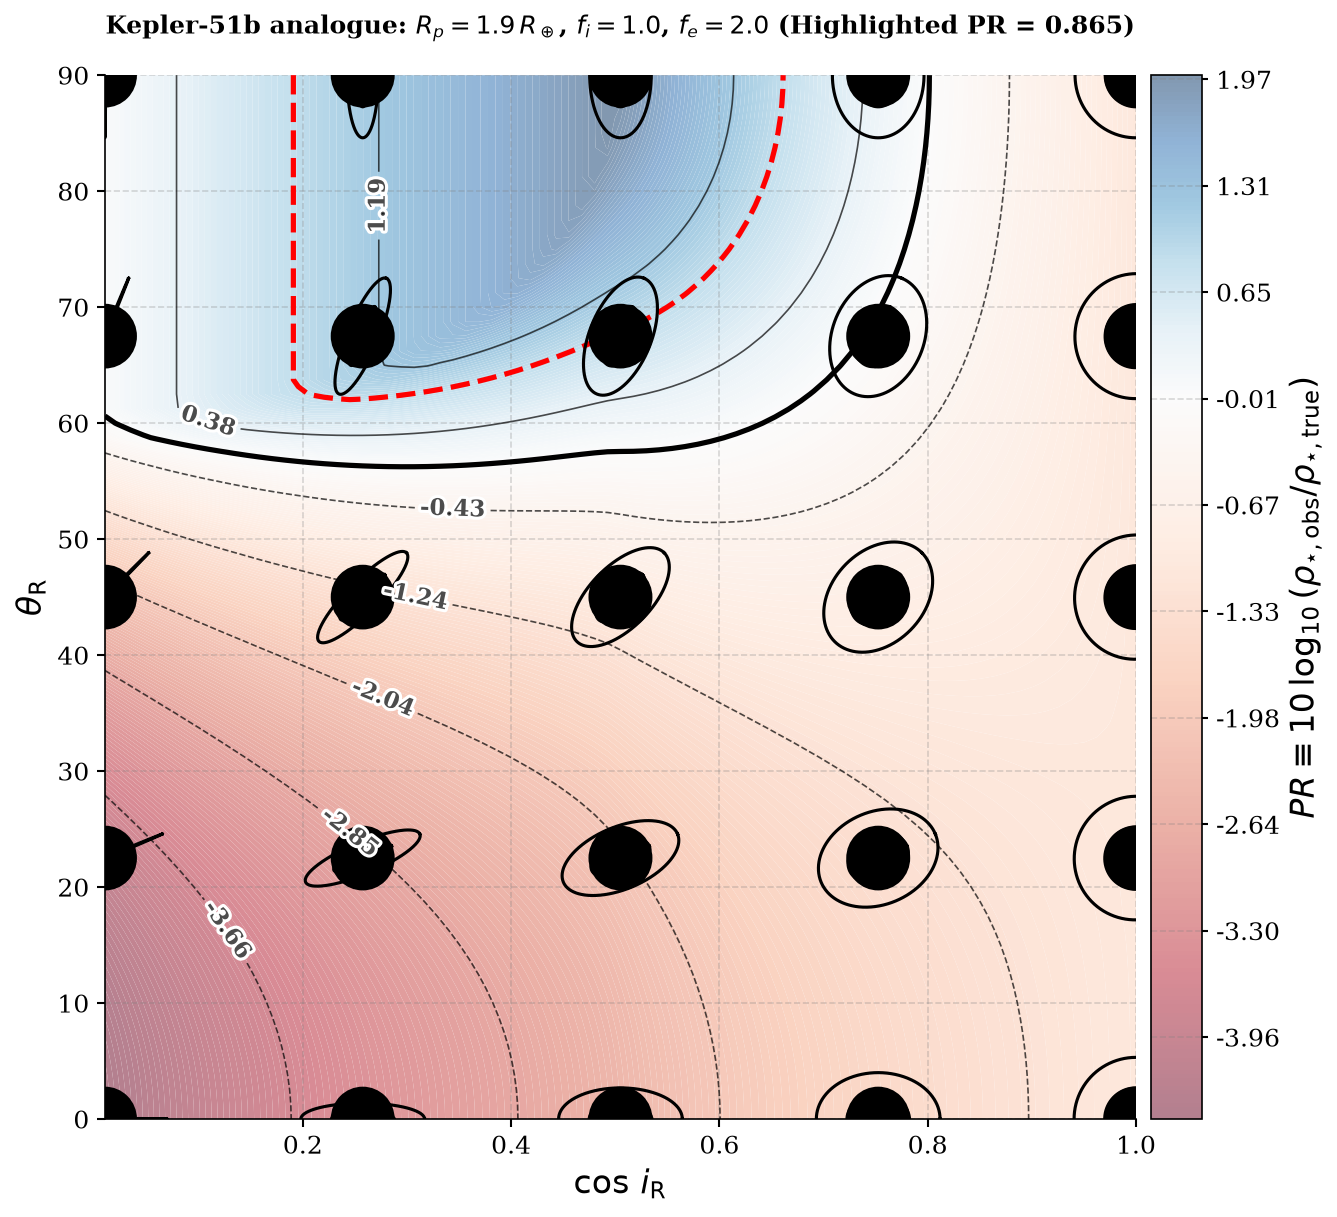

In [7]:
system = geo.dict2obj(dict(
    #########################################
    # SYSTEM PRIMARY PARAMETERS
    #########################################
    description="Kepler-51b analogue",
    # //////////////////////////////
    # DETECTOR
    # //////////////////////////////
    Ddet=0.5,       # Aperture, m
    qeff=1.0,       # Quantum efficiency
    # //////////////////////////////
    # STAR
    # //////////////////////////////
    Mstar=0.96*geo.MSUN,
    Rstar=0.87*geo.RSUN,
    Lstar=0.69*geo.LSUN,
    Tstar=0.98*geo.TSUN,
    Dstar=817*geo.PARSEC,
    c1=0.70,        # Limb Darkening
    c2=-0.24,       # Limb Darkening
    # //////////////////////////////
    # ORBIT
    # //////////////////////////////
    ap=0.25*geo.AU,
    ep=0.0,
    iorb=90.0*geo.DEG,
    wp=0.0*geo.DEG,
    # //////////////////////////////
    # PLANET
    # //////////////////////////////
    Mplanet=0.04*geo.MSAT, # 4 earth-masses
    Rplanet=0.21*geo.RSAT, # 1.9 earth-radii
    fp=0.0,         # Oblateness
    # //////////////////////////////
    # RINGS
    # //////////////////////////////
    fe=2.00,
    fi=1.01,
    ir=10.0*geo.DEG,        # Ring inclination
    phir=60.0*geo.DEG,      # Ring roll angle
    tau=1.0,            # Opacity
))

#########################################
# SYSTEM DERIVATIVE PARAMETERS
#########################################
geo.derivedSystemProperties(system)
geo.updatePlanetRings(system)
geo.updatePosition(system, system.tcen)

# Compute the contours
CI, TH, PR, Delta, ringed = compute_photoring_contour(system)

# Plot the contours
plot_contour(
    CI, TH, PR, ringed, 
    out_path="figures/PRContours-K51b.png",
    cbar_label=r"$PR\equiv10\,\log_{10}(\rho_{\star,\rm obs}/\rho_{\star,\rm true})$", 
    draw_zero=True,
    highlight_contour=0.865
)
